# Driver Distraction Classification — Lightweight CNN Comparison

차량 운전자 모니터링 시스템(DMS)을 위한 경량 CNN 4종의 정확도-효율성 트레이드오프 비교

- **데이터셋** -  State Farm Distracted Driver Detection (26명 운전자, 22,424장, 10개 부주의 행동 클래스)
- **비교 모델** -  MobileNetV3-Small, EfficientNet-B0, ResNet-18, ShuffleNetV2-x1.0
- **평가 지표** -  Top-1 정확도, Macro F1, 추론 지연시간(CPU/GPU), 파라미터 수, FLOPs
- **목표** - 차량 임베디드 환경에 적합한 경량 백본 선정

## 목차

1. [Setup & Dataset Download](#1-setup--dataset-download)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Data Preparation](#3-data-preparation)
4. [Models](#4-models)
5. [Training](#5-training)
6. [Benchmark & Evaluation](#6-benchmark--evaluation)
7. [Results & Visualization](#7-results--visualization)
8. [Conclusion](#8-conclusion)

## 1. Setup & Dataset Download

In [4]:
from dotenv import load_dotenv
import kagglehub, os

load_dotenv("/root/wjddnwp/KIIT_DMS_paper/.env")

path = kagglehub.competition_download('state-farm-distracted-driver-detection')
print("Path:", path)

100%|██████████| 4.00G/4.00G [06:45<00:00, 10.6MB/s]

Extracting files...


Path: /root/.cache/kagglehub/competitions/state-farm-distracted-driver-detection


## 2. Exploratory Data Analysis

In [5]:
import pandas as pd

DATA_ROOT = path
df = pd.read_csv(f"{DATA_ROOT}/driver_imgs_list.csv")
print(df.head())
print(f"\n운전자 수: {df['subject'].nunique()}")
print(f"클래스 수: {df['classname'].nunique()}")
print(f"총 이미지: {len(df)}")

  subject classname            img
0    p002        c0  img_44733.jpg
1    p002        c0  img_72999.jpg
2    p002        c0  img_25094.jpg
3    p002        c0  img_69092.jpg
4    p002        c0  img_92629.jpg

운전자 수: 26
클래스 수: 10
총 이미지: 22424


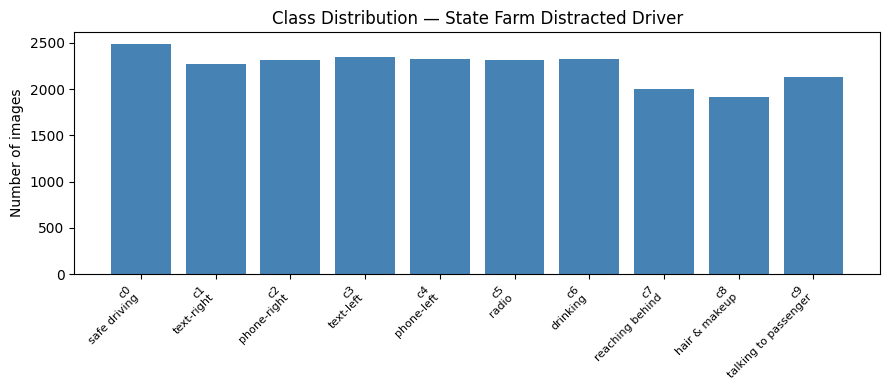

In [8]:
import matplotlib.pyplot as plt

CLASS_DESC = {
    "c0":"safe driving","c1":"text-right","c2":"phone-right","c3":"text-left",
    "c4":"phone-left","c5":"radio","c6":"drinking","c7":"reaching behind",
    "c8":"hair & makeup","c9":"talking to passenger"
}

counts = df['classname'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9,4))
ax.bar([f"{c}\n{CLASS_DESC[c]}" for c in counts.index], counts.values, color='steelblue')
ax.set_ylabel("Number of images")
ax.set_title("Class Distribution — State Farm Distracted Driver")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig("/root/wjddnwp/KIIT_DMS_paper/results/fig_class_dist.png", dpi=200)
plt.show()

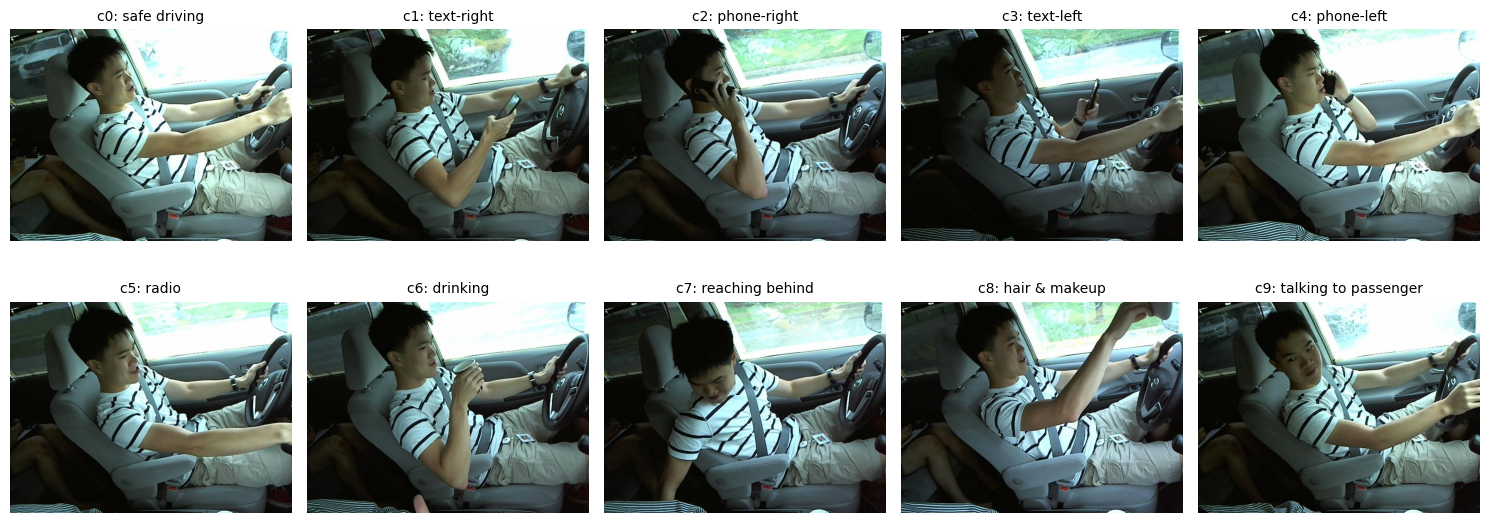

In [9]:
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, c in enumerate(sorted(df['classname'].unique())):
    sample = df[df['classname']==c].iloc[0]
    img = Image.open(f"{DATA_ROOT}/imgs/train/{c}/{sample['img']}")
    ax = axes[i//5, i%5]
    ax.imshow(img)
    ax.set_title(f"{c}: {CLASS_DESC[c]}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig("/root/wjddnwp/KIIT_DMS_paper/results/fig_class_samples.png", dpi=200)
plt.show()

In [10]:
driver_counts = df.groupby('subject').size().sort_values(ascending=False)
print("운전자별 이미지 수:")
print(driver_counts)
print(f"\n평균 {driver_counts.mean():.0f}장, 최소 {driver_counts.min()}, 최대 {driver_counts.max()}")

운전자별 이미지 수:
subject
p021    1237
p022    1233
p024    1226
p026    1196
p016    1078
p066    1034
p049    1011
p051     920
p014     876
p015     875
p035     848
p047     835
p081     823
p012     823
p064     820
p075     814
p061     809
p056     794
p050     790
p052     740
p002     725
p045     724
p039     651
p041     605
p042     591
p072     346
dtype: int64

평균 862장, 최소 346, 최대 1237


## 3. Data Preparation

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupKFold

CLASS_NAMES = [f"c{i}" for i in range(10)]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

class StateFarmDataset(Dataset):
    def __init__(self, sub_df, data_root, transform=None):
        self.df = sub_df.reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.data_root}/imgs/train/{row['classname']}/{row['img']}").convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, CLASS_TO_IDX[row['classname']]

FOLD = 0
gkf = GroupKFold(n_splits=5)
train_idx, val_idx = list(gkf.split(df, groups=df['subject']))[FOLD]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

train_ds = StateFarmDataset(df.iloc[train_idx], DATA_ROOT, train_tf)
val_ds   = StateFarmDataset(df.iloc[val_idx],   DATA_ROOT, val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# 운전자 누설 검증
train_drivers = set(df.iloc[train_idx]['subject'])
val_drivers   = set(df.iloc[val_idx]['subject'])
print(f"train: {len(train_ds)}장 / {len(train_drivers)}명")
print(f"val  : {len(val_ds)}장 / {len(val_drivers)}명")
print(f"운전자 겹침: {train_drivers & val_drivers} ")

train: 18017장 / 21명
val  : 4407장 / 5명
운전자 겹침: set() 


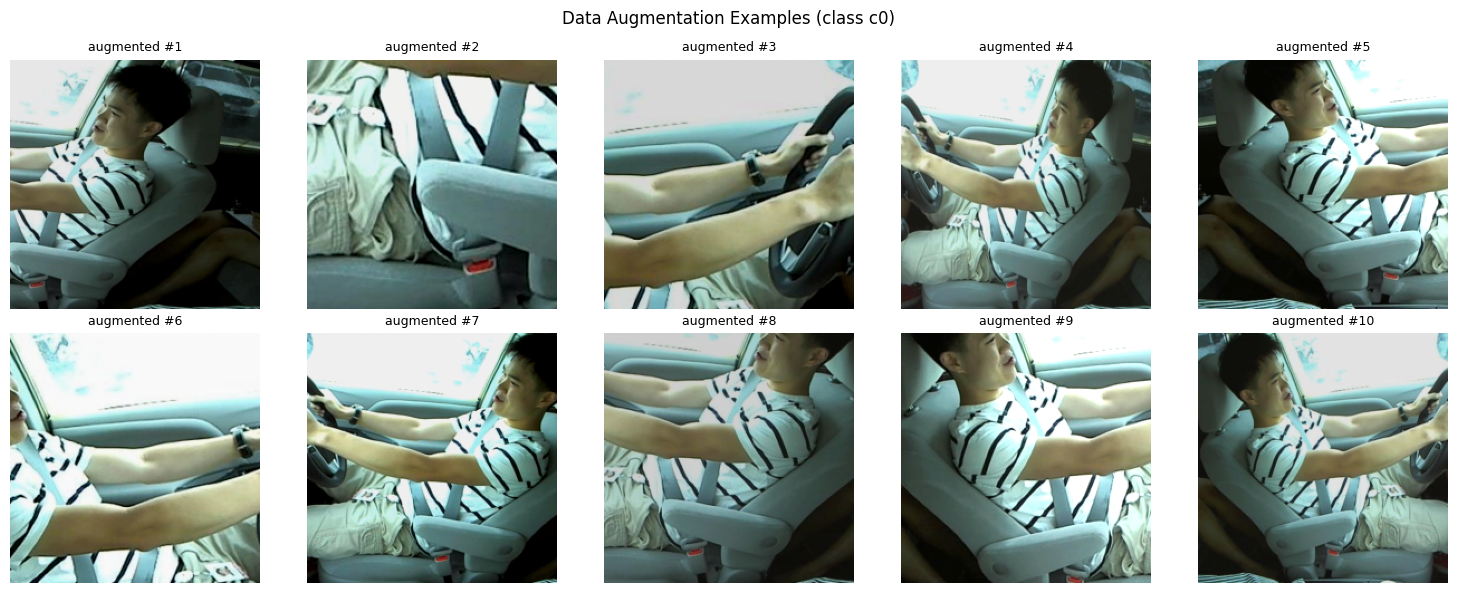

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_row = df.iloc[train_idx[0]]
raw = Image.open(f"{DATA_ROOT}/imgs/train/{sample_row['classname']}/{sample_row['img']}").convert("RGB")

inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225])

for i, ax in enumerate(axes.flat):
    aug = train_tf(raw)
    img_show = inv_norm(aug).permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img_show)
    ax.set_title(f"augmented #{i+1}", fontsize=9)
    ax.axis('off')
plt.suptitle(f"Data Augmentation Examples (class {sample_row['classname']})", fontsize=12)
plt.tight_layout()
plt.savefig("/root/wjddnwp/KIIT_DMS_paper/results/fig_augmentation.png", dpi=200)
plt.show()

## 4. Models

In [21]:
import timm
import torchvision.models as tvm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAMES = {
    "MobileNetV3-Small": "mobilenetv3_small_100",
    "EfficientNet-B0":   "efficientnet_b0",
    "ResNet-18":         "resnet18",
    "ShuffleNetV2-x1.0": "shufflenet_v2_x1_0",  
}

def build_model(model_id):
    if model_id == "shufflenet_v2_x1_0":
        m = tvm.shufflenet_v2_x1_0(weights=tvm.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, 10)
        return m.to(DEVICE)
    return timm.create_model(model_id, pretrained=True, num_classes=10).to(DEVICE)

In [15]:
from torch import nn, optim
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

CKPT_DIR = "/root/wjddnwp/KIIT_DMS_paper/checkpoints"

def train_one_model(model_key, epochs=30):
    model = build_model(MODEL_NAMES[model_key])
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()
    best_acc, best_path = 0, f"{CKPT_DIR}/{model_key}_best.pt"
    history = {"train_loss": [], "val_acc": []}

    for ep in range(1, epochs+1):
        model.train(); running = 0
        for imgs, labels in tqdm(train_loader, desc=f"[{model_key}] ep{ep}/{epochs}", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast():
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            running += loss.item()
        scheduler.step()
        train_loss = running / len(train_loader)

        model.eval(); correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                correct += (model(imgs).argmax(1) == labels).sum().item()
                total += len(labels)
        acc = correct / total
        history["train_loss"].append(train_loss)
        history["val_acc"].append(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), best_path)
        print(f"  ep{ep:02d}  loss={train_loss:.4f}  val_acc={acc:.4f}  best={best_acc:.4f}")

    print(f"\n[{model_key}] 완료 — best_acc={best_acc:.4f}\n")
    return {"acc": best_acc, "path": best_path, "history": history}

results = {}

## 5. Training

In [17]:
# MobileNetV3-Small
results["MobileNetV3-Small"] = train_one_model("MobileNetV3-Small")

model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

/tmp/ipykernel_280347/1511417538.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_280347/1511417538.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep01  loss=1.5984  val_acc=0.6764  best=0.6764


  ep02  loss=0.8053  val_acc=0.7291  best=0.7291


  ep03  loss=0.6757  val_acc=0.7456  best=0.7456


...

  ep26  loss=0.1510  val_acc=0.8087  best=0.8462


  ep27  loss=0.1455  val_acc=0.8344  best=0.8462


  ep28  loss=0.1361  val_acc=0.8337  best=0.8462


  ep29  loss=0.1342  val_acc=0.8357  best=0.8462


  ep30  loss=0.1424  val_acc=0.8362  best=0.8462

[MobileNetV3-Small] 완료 — best_acc=0.8462



In [18]:
# EfficientNet-B0
results["EfficientNet-B0"] = train_one_model("EfficientNet-B0")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

/tmp/ipykernel_280347/1511417538.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_280347/1511417538.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep01  loss=0.7104  val_acc=0.8389  best=0.8389


  ep02  loss=0.3920  val_acc=0.8112  best=0.8389


  ep03  loss=0.3274  val_acc=0.8255  best=0.8389


...

  ep26  loss=0.0718  val_acc=0.8144  best=0.8788


  ep27  loss=0.0704  val_acc=0.8405  best=0.8788


  ep28  loss=0.0676  val_acc=0.8509  best=0.8788


  ep29  loss=0.0681  val_acc=0.8568  best=0.8788


  ep30  loss=0.0703  val_acc=0.8355  best=0.8788

[EfficientNet-B0] 완료 — best_acc=0.8788



In [19]:
# ResNet-18
results["ResNet-18"] = train_one_model("ResNet-18")

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

/tmp/ipykernel_280347/1511417538.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_280347/1511417538.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep01  loss=0.8157  val_acc=0.8471  best=0.8471


  ep02  loss=0.4014  val_acc=0.8441  best=0.8471


  ep03  loss=0.3374  val_acc=0.8058  best=0.8471


...

  ep26  loss=0.0981  val_acc=0.8741  best=0.8958


  ep27  loss=0.0885  val_acc=0.8820  best=0.8958


  ep28  loss=0.0834  val_acc=0.8722  best=0.8958


  ep29  loss=0.0855  val_acc=0.8747  best=0.8958


  ep30  loss=0.0826  val_acc=0.8741  best=0.8958

[ResNet-18] 완료 — best_acc=0.8958



In [22]:
# ShuffleNetV2-x1.0
results["ShuffleNetV2-x1.0"] = train_one_model("ShuffleNetV2-x1.0")

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 11.6MB/s]
/tmp/ipykernel_280347/1511417538.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_280347/1511417538.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  ep01  loss=0.8450  val_acc=0.8575  best=0.8575


  ep02  loss=0.4427  val_acc=0.8818  best=0.8818


  ep03  loss=0.3950  val_acc=0.8763  best=0.8818


...

  ep26  loss=0.1044  val_acc=0.8700  best=0.8918


  ep27  loss=0.1036  val_acc=0.8450  best=0.8918


  ep28  loss=0.0982  val_acc=0.8446  best=0.8918


  ep29  loss=0.0956  val_acc=0.8580  best=0.8918


  ep30  loss=0.1011  val_acc=0.8620  best=0.8918

[ShuffleNetV2-x1.0] 완료 — best_acc=0.8918



## 6. Evaluation

In [23]:
import time
from fvcore.nn import FlopCountAnalysis

dummy_gpu = torch.randn(1, 3, 224, 224).to(DEVICE)
bench = {}

for key, model_id in MODEL_NAMES.items():
    model = build_model(model_id)
    model.eval()

    flops  = FlopCountAnalysis(model, dummy_gpu).total() / 1e9
    params = sum(p.numel() for p in model.parameters()) / 1e6
    size_mb = params * 4

    # GPU latency
    with torch.no_grad():
        for _ in range(50): model(dummy_gpu)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(200): model(dummy_gpu)
        torch.cuda.synchronize()
        gpu_ms = (time.perf_counter()-t0)/200*1000

    # CPU latency
    model_cpu = model.cpu()
    dummy_cpu = torch.randn(1, 3, 224, 224)
    with torch.no_grad():
        for _ in range(10): model_cpu(dummy_cpu)
        t0 = time.perf_counter()
        for _ in range(50): model_cpu(dummy_cpu)
        cpu_ms = (time.perf_counter()-t0)/50*1000

    bench[key] = dict(params=round(params,2), size_mb=round(size_mb,1),
                      gflops=round(flops,2), gpu_ms=round(gpu_ms,2), cpu_ms=round(cpu_ms,1))
    print(f"{key}: {params:.2f}M | {flops:.2f}G | GPU {gpu_ms:.2f}ms | CPU {cpu_ms:.1f}ms")
    del model, model_cpu
    torch.cuda.empty_cache()

Unsupported operator aten::hardswish_ encountered 19 time(s)
Unsupported operator aten::mean encountered 9 time(s)
Unsupported operator aten::hardsigmoid encountered 9 time(s)
Unsupported operator aten::mul encountered 9 time(s)
Unsupported operator aten::add encountered 6 time(s)


MobileNetV3-Small: 1.53M | 0.06G | GPU 2.97ms | CPU 10.0ms


Unsupported operator aten::silu_ encountered 49 time(s)
Unsupported operator aten::mean encountered 16 time(s)
Unsupported operator aten::sigmoid encountered 16 time(s)
Unsupported operator aten::mul encountered 16 time(s)
Unsupported operator aten::add encountered 9 time(s)


EfficientNet-B0: 4.02M | 0.40G | GPU 2.66ms | CPU 13.8ms


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)
Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::mean encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
stage2.1.branch1, stage2.2.branch1, stage2.3.branch1, stage3.1.branch1, stage3.2.branch1, stage3.3.branch1, stage3.4.branch1, stage3.5.branch1, stage3.6.branch1, stage3.7.branch1, stage4.1.branch1, stage4.2.branch1, stage4.3.branch1


ResNet-18: 11.18M | 1.82G | GPU 1.05ms | CPU 34.7ms
ShuffleNetV2-x1.0: 1.26M | 0.15G | GPU 2.95ms | CPU 12.4ms


In [24]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix
import numpy as np

final = {}
preds_store = {}

for key, model_id in MODEL_NAMES.items():
    model = build_model(model_id)
    model.load_state_dict(torch.load(results[key]["path"]))
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            preds.extend(model(imgs.to(DEVICE)).argmax(1).cpu().tolist())
            gts.extend(labels.tolist())
    preds_store[key] = (np.array(gts), np.array(preds))

    final[key] = {
        **bench[key],
        "top1": round(accuracy_score(gts, preds), 4),
        "macro_f1": round(f1_score(gts, preds, average='macro'), 4),
    }
    del model; torch.cuda.empty_cache()

df_final = pd.DataFrame(final).T[["params","size_mb","gflops","top1","macro_f1","gpu_ms","cpu_ms"]]
print(df_final)
df_final.to_csv("/root/wjddnwp/KIIT_DMS_paper/results/table1.csv")

                   params  size_mb  gflops    top1  macro_f1  gpu_ms  cpu_ms
MobileNetV3-Small    1.53      6.1    0.06  0.8462    0.8412    2.97    10.0
EfficientNet-B0      4.02     16.1    0.40  0.8788    0.8735    2.66    13.8
ResNet-18           11.18     44.7    1.82  0.8958    0.8888    1.05    34.7
ShuffleNetV2-x1.0    1.26      5.1    0.15  0.8918    0.8843    2.95    12.4


## 7. Results & Visualization

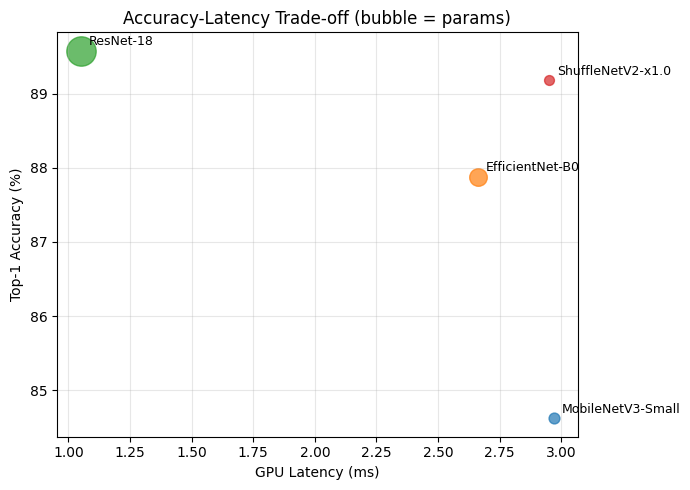

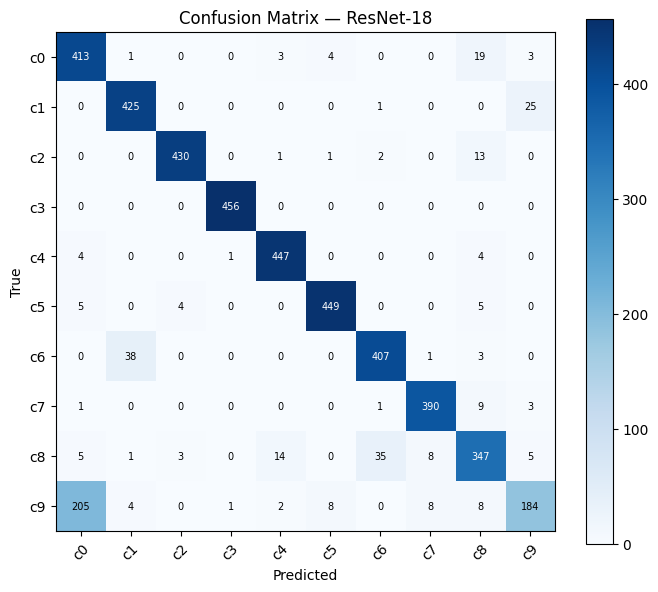

In [26]:
# accuracy-latency trade-off
fig, ax = plt.subplots(figsize=(7,5))
for key, row in df_final.iterrows():
    ax.scatter(row["gpu_ms"], row["top1"]*100, s=row["params"]*40, alpha=0.7)
    ax.annotate(key, (row["gpu_ms"], row["top1"]*100),
                textcoords="offset points", xytext=(6,4), fontsize=9)
ax.set_xlabel("GPU Latency (ms)")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.set_title("Accuracy-Latency Trade-off (bubble = params)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/root/wjddnwp/KIIT_DMS_paper/results/fig1_tradeoff.png", dpi=200)
plt.show()

# Confusion matrix (best model)
best_key = df_final["macro_f1"].idxmax()
gts, preds = preds_store[best_key]
cm = confusion_matrix(gts, preds)
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {best_key}")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=7,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig("/root/wjddnwp/KIIT_DMS_paper/results/fig_confusion.png", dpi=200)
plt.show()

  ## 8. Conclusion

  | 모델 | Params | Size | Top-1 | Macro F1 | GPU ms | CPU ms |
  |---|---|---|---|---|---|---|
  | MobileNetV3-Small | 1.53M | 6.1MB | 0.8462 | 0.8412 | 2.97 | 10.0 |
  | EfficientNet-B0 | 4.02M | 16.1MB | 0.8788 | 0.8735 | 2.66 | 13.8 |
  | ResNet-18 | 11.18M | 44.7MB | **0.8958** | **0.8888** | **1.05** | 34.7 |
  | ShuffleNetV2-x1.0 | **1.26M** | **5.1MB** | 0.8918 | 0.8843 | 2.95 | 12.4 |

  - 최고 정확도: **ResNet-18** (Top-1 89.58%)
  - 최소 모델 크기 및 최적 트레이드오프: **ShuffleNetV2-x1.0** (1.26M params, 5.1MB, Top-1
  89.18%)
  - 최저 CPU 지연: **MobileNetV3-Small** (10.0 ms)